In [1]:

import numpy as np                 # for numeric operations
import pandas as pd                # for working with tables (DataFrames)
import matplotlib.pyplot as plt    # for basic plots
import seaborn as sns              # for nicer, easier statistical plots
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:

def print_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"Model: {model_name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

def show_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


In [3]:
student_df = pd.read_csv("StudentsPerformance.csv")

print("Shape of dataset (rows, columns):", student_df.shape)
student_df.head()

Shape of dataset (rows, columns): (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
student_df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
print("Missing values in each column:")
print(student_df.isnull().sum())

print("\nNumber of duplicate rows:", student_df.duplicated().sum())

student_df = student_df.drop_duplicates()
print("\nShape after removing duplicates:", student_df.shape)

Missing values in each column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Number of duplicate rows: 0

Shape after removing duplicates: (1000, 8)


In [7]:
student_df["average_score"] = (student_df["math score"] +
                                student_df["reading score"] +
                                student_df["writing score"]) / 3

student_df["result"] = np.where(student_df["average_score"] >= 50, "Pass", "Fail")

print(student_df["result"].value_counts())
student_df[["math score", "reading score", "writing score", "average_score", "result"]].head()

result
Pass    897
Fail    103
Name: count, dtype: int64


,math score,reading score,writing score,average_score,result
0,72,72,74,72.666667,Pass
1,69,90,88,82.333333,Pass
2,90,95,93,92.666667,Pass
3,47,57,44,49.333333,Fail
4,76,78,75,76.333333,Pass


In [8]:
student_encoded = student_df.copy()

categorical_columns = ["gender", "race/ethnicity", "parental level of education",
                        "lunch", "test preparation course"]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    student_encoded[col] = le.fit_transform(student_encoded[col])
    encoders[col] = le
    print(f"{col}: {list(le.classes_)}  ->  {list(range(len(le.classes_)))}")

result_encoder = LabelEncoder()
student_encoded["result"] = result_encoder.fit_transform(student_encoded["result"])

student_encoded.head()

gender: ['female', 'male']  ->  [0, 1]
race/ethnicity: ['group A', 'group B', 'group C', 'group D', 'group E']  ->  [0, 1, 2, 3, 4]
parental level of education: ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']  ->  [0, 1, 2, 3, 4, 5]
lunch: ['free/reduced', 'standard']  ->  [0, 1]
test preparation course: ['completed', 'none']  ->  [0, 1]


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\1378098753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="result", data=student_df, palette="Set2")


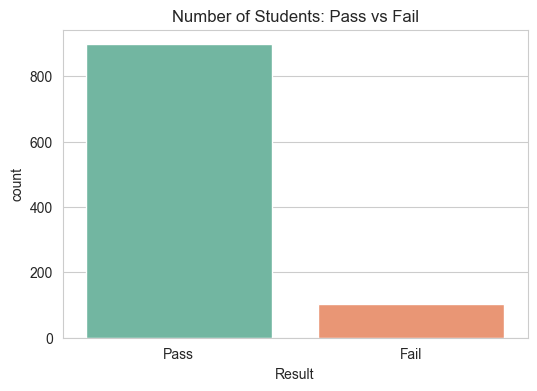

In [9]:
plt.figure()
sns.countplot(x="result", data=student_df, palette="Set2")
plt.title("Number of Students: Pass vs Fail")
plt.xlabel("Result")
plt.show()

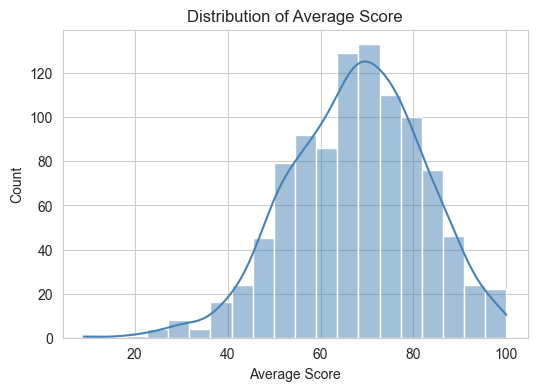

In [10]:
plt.figure()
sns.histplot(student_df["average_score"], kde=True, bins=20, color="steelblue")
plt.title("Distribution of Average Score")
plt.xlabel("Average Score")
plt.show()

C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\1328072405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="test preparation course", y="average_score", data=student_df, palette="Set3")


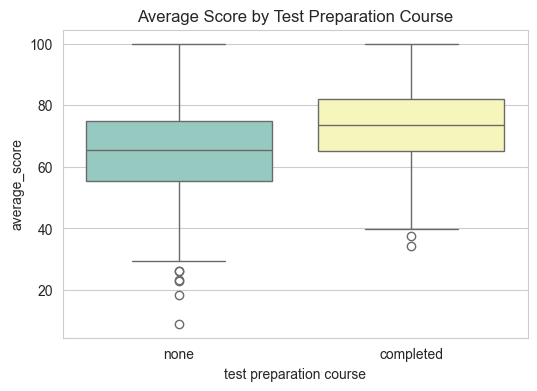

In [11]:
plt.figure()
sns.boxplot(x="test preparation course", y="average_score", data=student_df, palette="Set3")
plt.title("Average Score by Test Preparation Course")
plt.show()

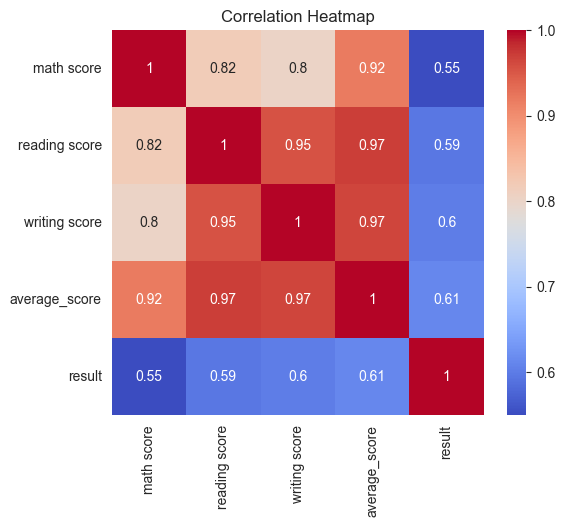

In [12]:
plt.figure(figsize=(6, 5))
numeric_cols = student_encoded[["math score", "reading score", "writing score",
                                 "average_score", "result"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
feature_columns = ["gender", "race/ethnicity", "parental level of education", "lunch",
                    "test preparation course", "math score", "reading score", "writing score"]

X = student_encoded[feature_columns]
y = student_encoded["result"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 8)
Target shape: (1000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 800
Testing samples : 200


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn the scale from training data
X_test_scaled = scaler.transform(X_test)         # apply the SAME scale to test data

print("Scaling done.")

Scaling done.


In [16]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_model.fit(X_train_scaled, y_train)

log_reg_pred = log_reg_model.predict(X_test_scaled)
log_reg_acc, log_reg_prec, log_reg_rec, log_reg_f1 = print_metrics("Logistic Regression", y_test, log_reg_pred)

Model: Logistic Regression
  Accuracy  : 0.9950
  Precision : 0.9950
  Recall    : 0.9950
  F1-Score  : 0.9949


In [17]:
decision_tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_model.fit(X_train_scaled, y_train)

decision_tree_pred = decision_tree_model.predict(X_test_scaled)
dt_acc, dt_prec, dt_rec, dt_f1 = print_metrics("Decision Tree", y_test, decision_tree_pred)

Model: Decision Tree
  Accuracy  : 0.9800
  Precision : 0.9800
  Recall    : 0.9800
  F1-Score  : 0.9800


In [18]:
random_forest_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
random_forest_model.fit(X_train_scaled, y_train)

random_forest_pred = random_forest_model.predict(X_test_scaled)
rf_acc, rf_prec, rf_rec, rf_f1 = print_metrics("Random Forest", y_test, random_forest_pred)

Model: Random Forest
  Accuracy  : 0.9850
  Precision : 0.9848
  Recall    : 0.9850
  F1-Score  : 0.9848


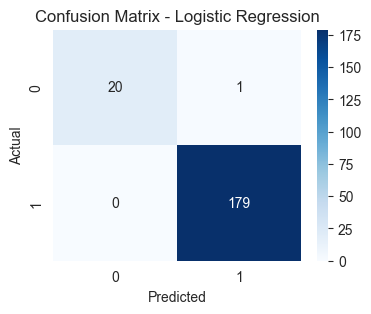

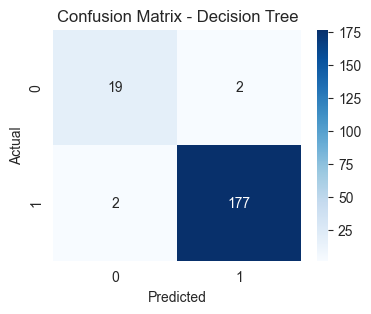

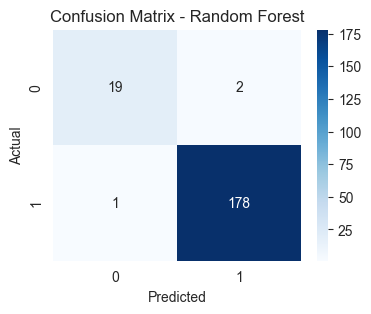

In [19]:
show_confusion_matrix("Logistic Regression", y_test, log_reg_pred)
show_confusion_matrix("Decision Tree", y_test, decision_tree_pred)
show_confusion_matrix("Random Forest", y_test, random_forest_pred)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.995   0.995028   0.995  0.994946
1        Decision Tree     0.980   0.980000   0.980  0.980000
2        Random Forest     0.985   0.984806   0.985  0.984838


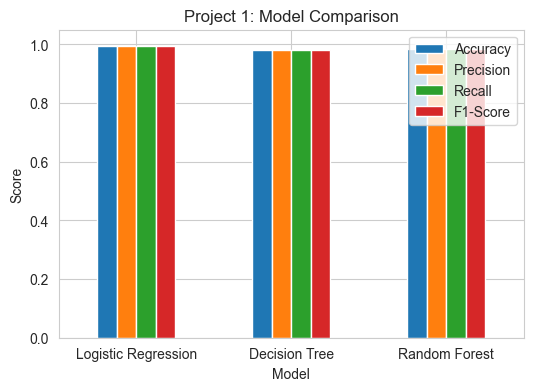


Best Model: Logistic Regression


In [20]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_reg_acc, dt_acc, rf_acc],
    "Precision": [log_reg_prec, dt_prec, rf_prec],
    "Recall": [log_reg_rec, dt_rec, rf_rec],
    "F1-Score": [log_reg_f1, dt_f1, rf_f1],
})

print(comparison_table)

comparison_table.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1-Score"], kind="bar")
plt.title("Project 1: Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

best_row = comparison_table.sort_values("F1-Score", ascending=False).iloc[0]
print("\nBest Model:", best_row["Model"])

In [21]:
def predict_student_result(gender, ethnicity, parent_education, lunch, test_prep,
                            math_score, reading_score, writing_score):
    new_student = pd.DataFrame([{
        "gender": gender,
        "race/ethnicity": ethnicity,
        "parental level of education": parent_education,
        "lunch": lunch,
        "test preparation course": test_prep,
        "math score": math_score,
        "reading score": reading_score,
        "writing score": writing_score,
    }])

    for col in categorical_columns:
        new_student[col] = encoders[col].transform(new_student[col])

    new_student = new_student[feature_columns]
    new_student_scaled = scaler.transform(new_student)

    prediction = random_forest_model.predict(new_student_scaled)[0]
    return result_encoder.inverse_transform([prediction])[0]


result = predict_student_result(
    gender="female",
    ethnicity="group B",
    parent_education="bachelor's degree",
    lunch="standard",
    test_prep="completed",
    math_score=75,
    reading_score=80,
    writing_score=78,
)
print("Predicted Result:", result)

Predicted Result: Pass


In [22]:
diabetes_df = pd.read_csv("diabetes.csv")

print("Shape:", diabetes_df.shape)
diabetes_df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [25]:
print("Duplicate rows:", diabetes_df.duplicated().sum())
diabetes_df = diabetes_df.drop_duplicates()

columns_with_hidden_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_with_hidden_missing:
    zero_count = (diabetes_df[col] == 0).sum()
    print(f"{col}: {zero_count} hidden missing values (zeros)")
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)

for col in columns_with_hidden_missing:
    diabetes_df[col] = diabetes_df[col].fillna(diabetes_df[col].median())

print("\nMissing values after cleaning:", diabetes_df.isnull().sum().sum())

Duplicate rows: 0
Glucose: 5 hidden missing values (zeros)
BloodPressure: 35 hidden missing values (zeros)
SkinThickness: 227 hidden missing values (zeros)
Insulin: 374 hidden missing values (zeros)
BMI: 11 hidden missing values (zeros)

Missing values after cleaning: 0


C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\2091001099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=diabetes_df, palette="Set2")


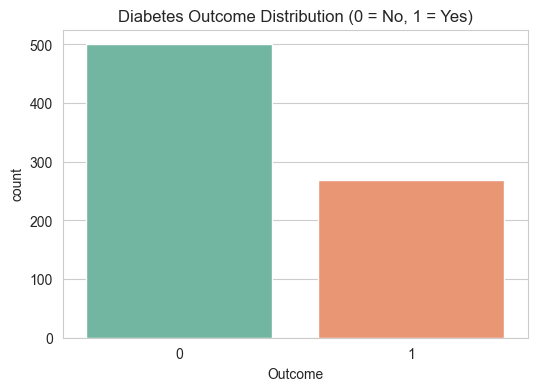

In [26]:
plt.figure()
sns.countplot(x="Outcome", data=diabetes_df, palette="Set2")
plt.title("Diabetes Outcome Distribution (0 = No, 1 = Yes)")
plt.show()

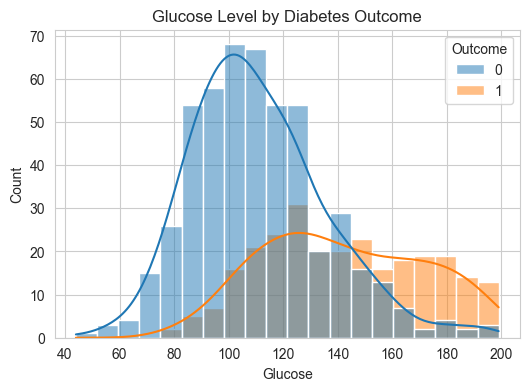

In [27]:
plt.figure()
sns.histplot(data=diabetes_df, x="Glucose", hue="Outcome", kde=True, bins=20)
plt.title("Glucose Level by Diabetes Outcome")
plt.show()

C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\2033472127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="BMI", data=diabetes_df, palette="Set3")


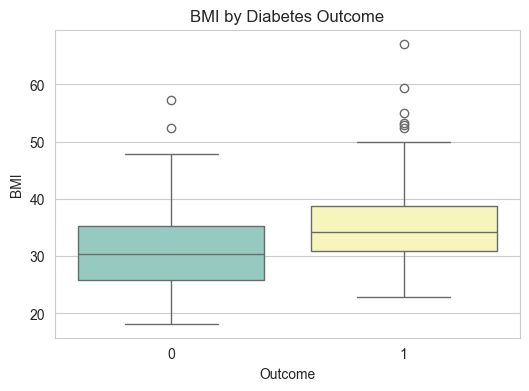

In [28]:
plt.figure()
sns.boxplot(x="Outcome", y="BMI", data=diabetes_df, palette="Set3")
plt.title("BMI by Diabetes Outcome")
plt.show()

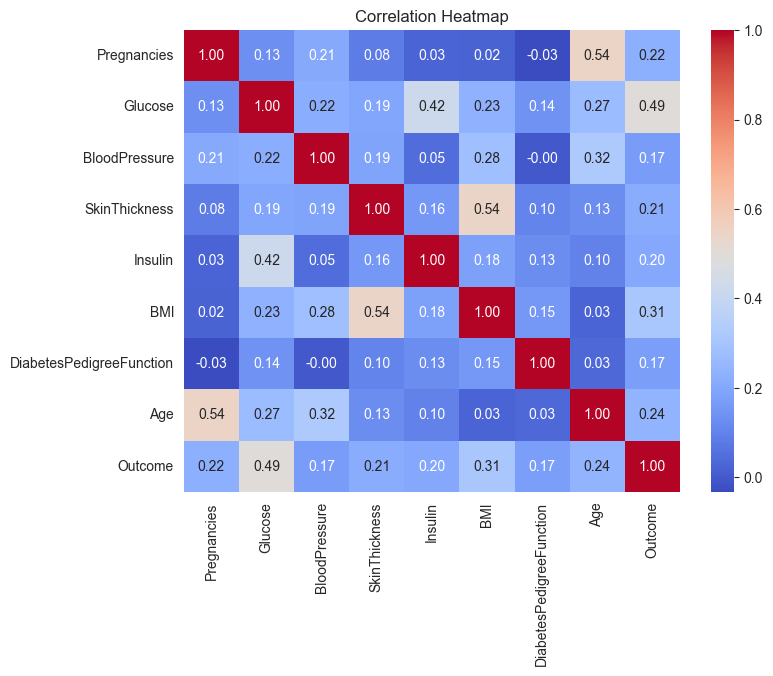

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(diabetes_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [30]:
X_dia = diabetes_df.drop(columns=["Outcome"])
y_dia = diabetes_df["Outcome"]

X_dia_train, X_dia_test, y_dia_train, y_dia_test = train_test_split(
    X_dia, y_dia, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dia
)

dia_scaler = StandardScaler()
X_dia_train_scaled = dia_scaler.fit_transform(X_dia_train)
X_dia_test_scaled = dia_scaler.transform(X_dia_test)

print("Training samples:", X_dia_train.shape[0])
print("Testing samples :", X_dia_test.shape[0])

Training samples: 614
Testing samples : 154


In [31]:
dia_log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
dia_log_model.fit(X_dia_train_scaled, y_dia_train)
dia_log_pred = dia_log_model.predict(X_dia_test_scaled)
dia_log_acc, dia_log_prec, dia_log_rec, dia_log_f1 = print_metrics("Logistic Regression", y_dia_test, dia_log_pred)

Model: Logistic Regression
  Accuracy  : 0.7078
  Precision : 0.6989
  Recall    : 0.7078
  F1-Score  : 0.7008


In [32]:
dia_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dia_dt_model.fit(X_dia_train_scaled, y_dia_train)
dia_dt_pred = dia_dt_model.predict(X_dia_test_scaled)
dia_dt_acc, dia_dt_prec, dia_dt_rec, dia_dt_f1 = print_metrics("Decision Tree", y_dia_test, dia_dt_pred)

Model: Decision Tree
  Accuracy  : 0.6818
  Precision : 0.6734
  Recall    : 0.6818
  F1-Score  : 0.6762


In [33]:
dia_rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
dia_rf_model.fit(X_dia_train_scaled, y_dia_train)
dia_rf_pred = dia_rf_model.predict(X_dia_test_scaled)
dia_rf_acc, dia_rf_prec, dia_rf_rec, dia_rf_f1 = print_metrics("Random Forest", y_dia_test, dia_rf_pred)

Model: Random Forest
  Accuracy  : 0.7403
  Precision : 0.7337
  Recall    : 0.7403
  F1-Score  : 0.7349


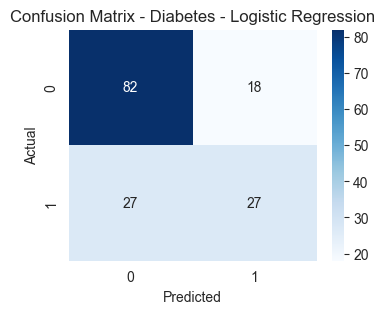

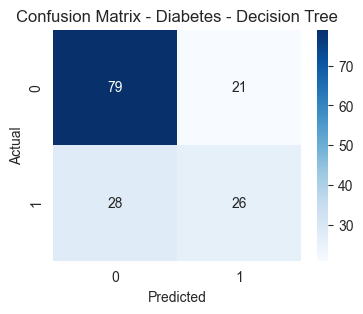

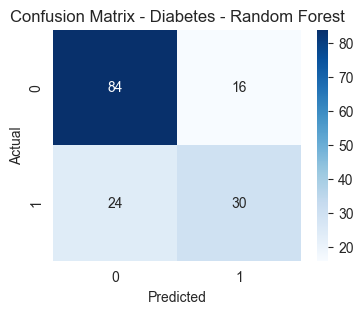

In [34]:
show_confusion_matrix("Diabetes - Logistic Regression", y_dia_test, dia_log_pred)
show_confusion_matrix("Diabetes - Decision Tree", y_dia_test, dia_dt_pred)
show_confusion_matrix("Diabetes - Random Forest", y_dia_test, dia_rf_pred)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.707792   0.698892  0.707792  0.700802
1        Decision Tree  0.681818   0.673403  0.681818  0.676172
2        Random Forest  0.740260   0.733735  0.740260  0.734865


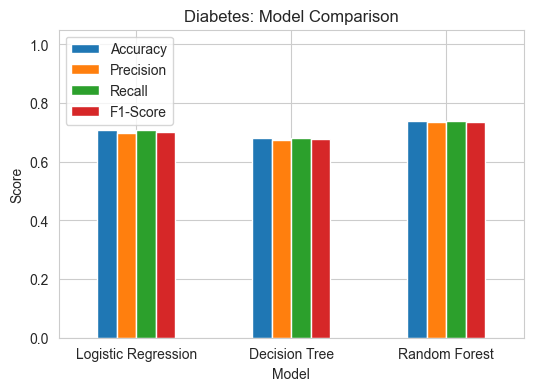


Best Model: Random Forest


In [35]:
dia_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [dia_log_acc, dia_dt_acc, dia_rf_acc],
    "Precision": [dia_log_prec, dia_dt_prec, dia_rf_prec],
    "Recall": [dia_log_rec, dia_dt_rec, dia_rf_rec],
    "F1-Score": [dia_log_f1, dia_dt_f1, dia_rf_f1],
})
print(dia_comparison)

dia_comparison.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1-Score"], kind="bar")
plt.title("Diabetes: Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

dia_best = dia_comparison.sort_values("F1-Score", ascending=False).iloc[0]
print("\nBest Model:", dia_best["Model"])

In [36]:
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                      insulin, bmi, diabetes_pedigree, age):
    new_patient = pd.DataFrame([{
        "Pregnancies": pregnancies, "Glucose": glucose, "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness, "Insulin": insulin, "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree, "Age": age
    }])
    new_patient_scaled = dia_scaler.transform(new_patient)
    prediction = dia_rf_model.predict(new_patient_scaled)[0]   # using Random Forest here
    return "Diabetic" if prediction == 1 else "Not Diabetic"

print(predict_diabetes(pregnancies=2, glucose=150, blood_pressure=80, skin_thickness=25,
                        insulin=100, bmi=33.5, diabetes_pedigree=0.6, age=45))

Diabetic


In [37]:
heart_df = pd.read_csv("heart.csv")

print("Shape:", heart_df.shape)
heart_df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [38]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [39]:
print("Missing values:\n", heart_df.isnull().sum())
print("\nDuplicate rows:", heart_df.duplicated().sum())

heart_df = heart_df.drop_duplicates()
print("\nShape after removing duplicates:", heart_df.shape)


Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 723

Shape after removing duplicates: (302, 14)


C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\1954549830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=heart_df, palette="Set2")


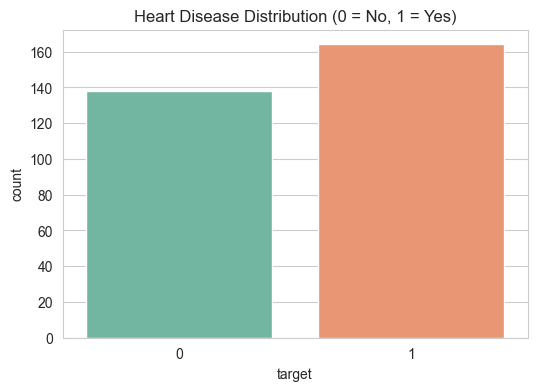

In [40]:
plt.figure()
sns.countplot(x="target", data=heart_df, palette="Set2")
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

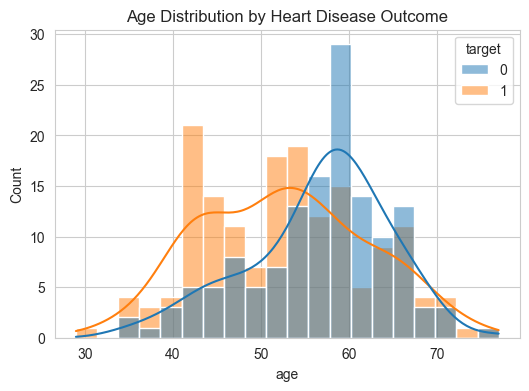

In [41]:
plt.figure()
sns.histplot(data=heart_df, x="age", hue="target", kde=True, bins=20)
plt.title("Age Distribution by Heart Disease Outcome")
plt.show()

C:\Users\Kushagra Gupta\AppData\Local\Temp\ipykernel_23372\1351403551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="thalach", data=heart_df, palette="Set3")


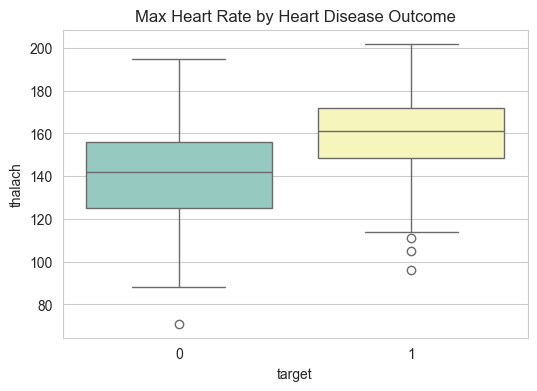

In [42]:
plt.figure()
sns.boxplot(x="target", y="thalach", data=heart_df, palette="Set3")
plt.title("Max Heart Rate by Heart Disease Outcome")
plt.show()

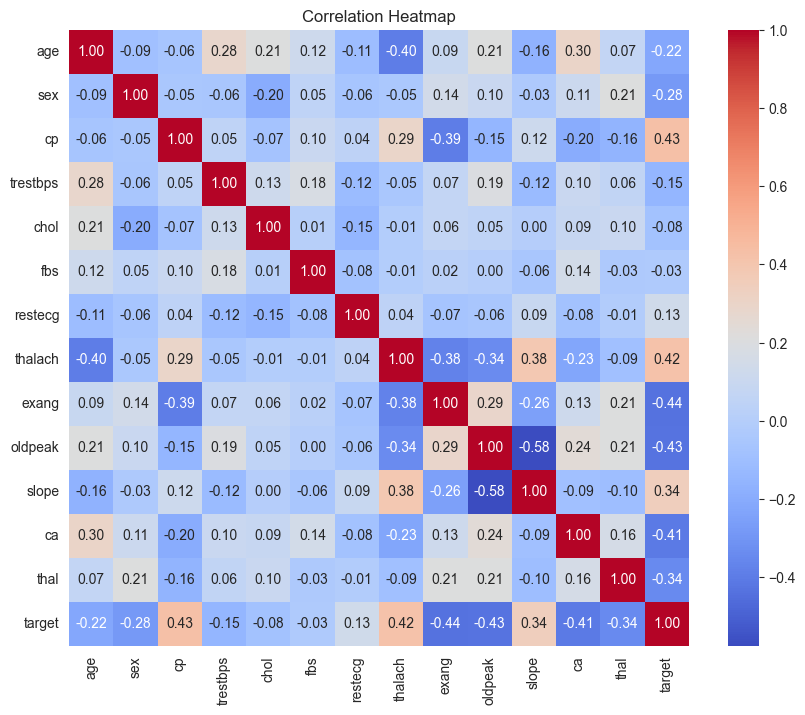

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(heart_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
X_heart = heart_df.drop(columns=["target"])
y_heart = heart_df["target"]

X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=RANDOM_STATE, stratify=y_heart
)

heart_scaler = StandardScaler()
X_heart_train_scaled = heart_scaler.fit_transform(X_heart_train)
X_heart_test_scaled = heart_scaler.transform(X_heart_test)

print("Training samples:", X_heart_train.shape[0])
print("Testing samples :", X_heart_test.shape[0])

Training samples: 241
Testing samples : 61


In [45]:
heart_log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
heart_log_model.fit(X_heart_train_scaled, y_heart_train)
heart_log_pred = heart_log_model.predict(X_heart_test_scaled)
heart_log_acc, heart_log_prec, heart_log_rec, heart_log_f1 = print_metrics("Logistic Regression", y_heart_test, heart_log_pred)

Model: Logistic Regression
  Accuracy  : 0.8033
  Precision : 0.8035
  Recall    : 0.8033
  F1-Score  : 0.8025


In [46]:
heart_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
heart_dt_model.fit(X_heart_train_scaled, y_heart_train)
heart_dt_pred = heart_dt_model.predict(X_heart_test_scaled)
heart_dt_acc, heart_dt_prec, heart_dt_rec, heart_dt_f1 = print_metrics("Decision Tree", y_heart_test, heart_dt_pred)

Model: Decision Tree
  Accuracy  : 0.8033
  Precision : 0.8033
  Recall    : 0.8033
  F1-Score  : 0.8033


In [47]:
heart_rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
heart_rf_model.fit(X_heart_train_scaled, y_heart_train)
heart_rf_pred = heart_rf_model.predict(X_heart_test_scaled)
heart_rf_acc, heart_rf_prec, heart_rf_rec, heart_rf_f1 = print_metrics("Random Forest", y_heart_test, heart_rf_pred)

Model: Random Forest
  Accuracy  : 0.7541
  Precision : 0.7537
  Recall    : 0.7541
  F1-Score  : 0.7537


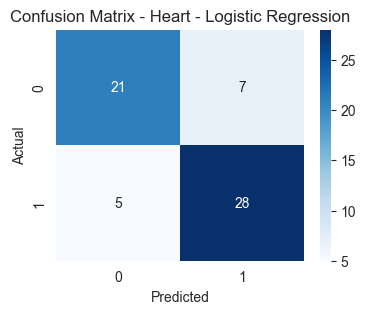

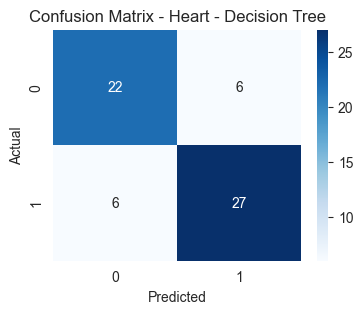

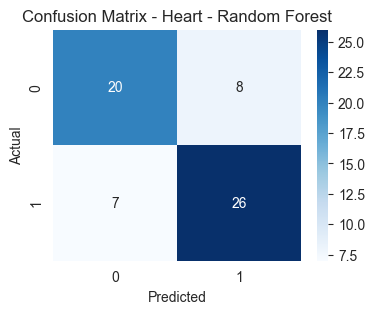

In [48]:
show_confusion_matrix("Heart - Logistic Regression", y_heart_test, heart_log_pred)
show_confusion_matrix("Heart - Decision Tree", y_heart_test, heart_dt_pred)
show_confusion_matrix("Heart - Random Forest", y_heart_test, heart_rf_pred)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.803279   0.803531  0.803279  0.802529
1        Decision Tree  0.803279   0.803279  0.803279  0.803279
2        Random Forest  0.754098   0.753705  0.754098  0.753698


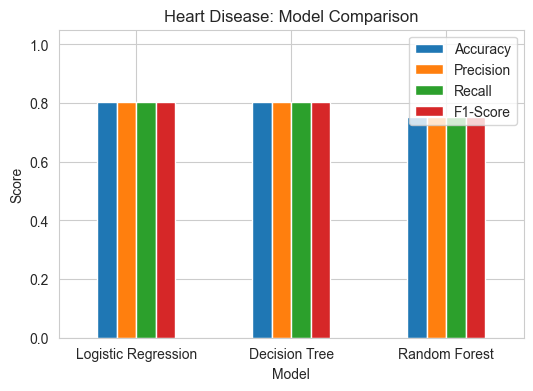


Best Model: Decision Tree


In [49]:
heart_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [heart_log_acc, heart_dt_acc, heart_rf_acc],
    "Precision": [heart_log_prec, heart_dt_prec, heart_rf_prec],
    "Recall": [heart_log_rec, heart_dt_rec, heart_rf_rec],
    "F1-Score": [heart_log_f1, heart_dt_f1, heart_rf_f1],
})
print(heart_comparison)

heart_comparison.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1-Score"], kind="bar")
plt.title("Heart Disease: Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

heart_best = heart_comparison.sort_values("F1-Score", ascending=False).iloc[0]
print("\nBest Model:", heart_best["Model"])

In [50]:
def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg, thalach,
                           exang, oldpeak, slope, ca, thal):
    new_patient = pd.DataFrame([{
        "age": age, "sex": sex, "cp": cp, "trestbps": trestbps, "chol": chol, "fbs": fbs,
        "restecg": restecg, "thalach": thalach, "exang": exang, "oldpeak": oldpeak,
        "slope": slope, "ca": ca, "thal": thal
    }])
    new_patient_scaled = heart_scaler.transform(new_patient)
    prediction = heart_rf_model.predict(new_patient_scaled)[0]   # using Random Forest here
    return "Heart Disease Present" if prediction == 1 else "No Heart Disease"

print(predict_heart_disease(age=58, sex=1, cp=2, trestbps=140, chol=260, fbs=0,
                             restecg=1, thalach=132, exang=1, oldpeak=2.1,
                             slope=1, ca=1, thal=2))

No Heart Disease
